In [1]:
import torch
from dataloader import get_fashionmnist_loaders
from CNN import ClassificationNetwork
import torch.nn as nn
import matplotlib.pyplot as plt
from ViT import VisionTransformer
import train 

### ViT vs CNN on fashionMNIST 

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Récupération des DataLoader FashionMNIST
train_loader, test_loader = get_fashionmnist_loaders(batch_size=64, input_size=28)

torch.Size([64, 1, 28, 28])
torch.Size([64])
taille du dataset d'entrainement en nbr de batch: 938
taille du dataset de test en nbr de batch: 157


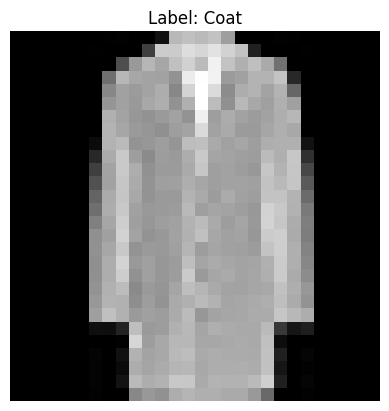

In [4]:
classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

images, labels = next(iter(train_loader))
print(images.shape)  # doit être: (batch_size, 3, 32, 32)
print(labels.shape)  # (batch_size,)
print(f"taille du dataset d'entrainement en nbr de batch: {len(train_loader)}")
print(f"taille du dataset de test en nbr de batch: {len(test_loader)}")

image, label = images[0], labels[0]

# image: (3, 32, 32) → (32, 32, 3)
image = image.permute(1, 2, 0)

plt.imshow(image, cmap="gray")
plt.title(f"Label: {classes[label]}") #pour avoir le nom de la classe associée au label
plt.axis("off")
plt.show()

Fashion MNIST: image d'habits ou accesoires 
- 28*28 pixel
- noir et blanc (1 channel)
- 10 classes
- train : 60 000 images labelisées
- test : 10 000 images labelisées 

Grand dataset d'images en noir et blanc de faible résolution (petite taille) avec uniquement 10 classes. 

On a implémenté pour cette partie un CNN constitué de 4 blocs convolutionnels, chacun suivi d’une activation ReLU et d’un max pooling (réduction progressive de la taille spatiale, augmentation du nombre de canaux) puis d'une couche fully connected. 

In [5]:
model_cnn = ClassificationNetwork(num_classes=10, in_channels=1, input_size=28).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_cnn.parameters(), lr=3e-4, weight_decay=1e-4)

In [6]:
train_losses, val_losses, train_accuracies, val_accuracies = train.train(
    model_cnn, train_loader, test_loader, optimizer, criterion, device, num_epochs=20
)

Epoch [1/20] Train Loss: 0.6607, Train Acc: 75.49% | Val Loss: 0.4657, Val Acc: 82.48%
Epoch [2/20] Train Loss: 0.3869, Train Acc: 85.94% | Val Loss: 0.3714, Val Acc: 86.48%
Epoch [3/20] Train Loss: 0.3197, Train Acc: 88.36% | Val Loss: 0.3183, Val Acc: 88.21%
Epoch [4/20] Train Loss: 0.2830, Train Acc: 89.64% | Val Loss: 0.2949, Val Acc: 88.90%
Epoch [5/20] Train Loss: 0.2579, Train Acc: 90.59% | Val Loss: 0.2696, Val Acc: 90.32%
Epoch [6/20] Train Loss: 0.2352, Train Acc: 91.41% | Val Loss: 0.2718, Val Acc: 89.98%
Epoch [7/20] Train Loss: 0.2197, Train Acc: 91.99% | Val Loss: 0.2598, Val Acc: 90.67%
Epoch [8/20] Train Loss: 0.2044, Train Acc: 92.50% | Val Loss: 0.2560, Val Acc: 90.70%
Epoch [9/20] Train Loss: 0.1889, Train Acc: 93.15% | Val Loss: 0.2571, Val Acc: 90.76%
Epoch [10/20] Train Loss: 0.1768, Train Acc: 93.51% | Val Loss: 0.2552, Val Acc: 90.86%
Epoch [11/20] Train Loss: 0.1627, Train Acc: 94.02% | Val Loss: 0.2441, Val Acc: 91.78%
Epoch [12/20] Train Loss: 0.1504, Train A

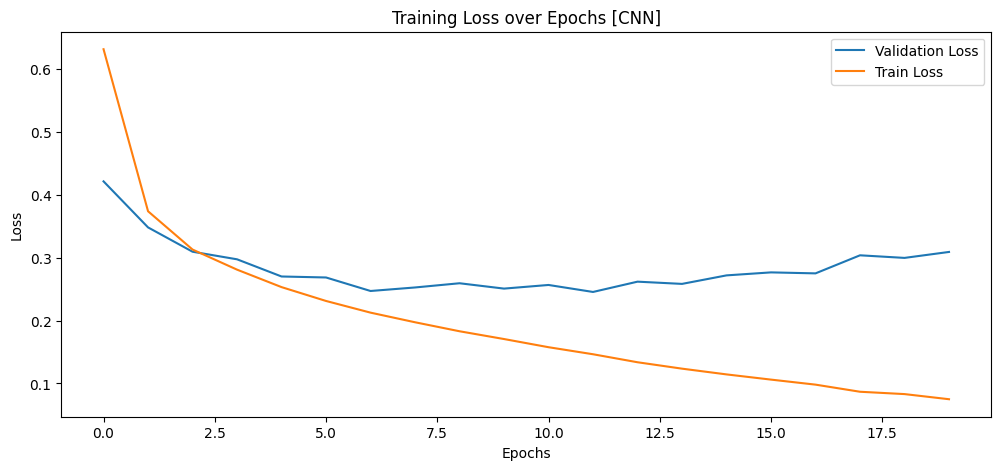

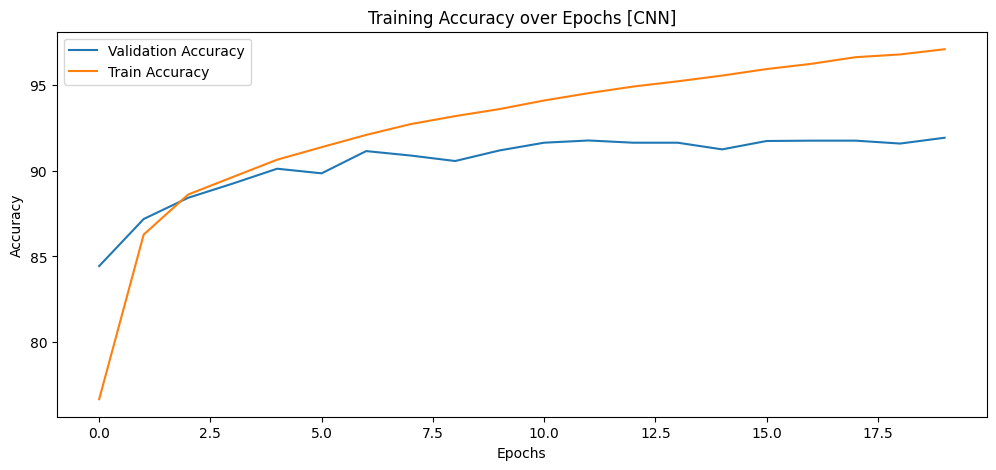

In [6]:
# Tracer les courbes de loss
plt.figure(figsize=(12, 5))
plt.plot(val_losses, label='Validation Loss')
plt.plot(train_losses, label='Train Loss')
plt.title('Training Loss over Epochs [CNN]')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()  

# courbe d'accuracy
plt.figure(figsize=(12, 5))
plt.plot(val_accuracies, label='Validation Accuracy')
plt.plot(train_accuracies, label='Train Accuracy')
plt.title('Training Accuracy over Epochs [CNN]')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

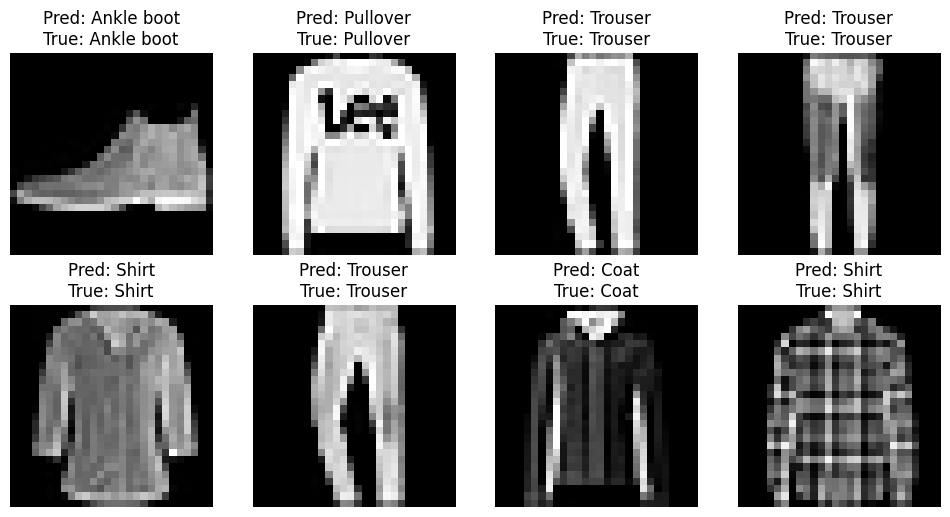

In [12]:
import matplotlib.pyplot as plt
import numpy as np

model_cnn.eval()
classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
outputs = model_cnn(images)
_, preds = torch.max(outputs, 1)

# Affichage de 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    img = images[i].cpu().numpy().transpose(1, 2, 0)
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"Pred: {classes[preds[i]]}\nTrue: {classes[labels[i]]}")
    ax.axis('off')
plt.show()

In [7]:
model_vit = VisionTransformer(
    img_size=28,
    patch_size=4,
    in_channels=1,
    hidden_dim=128,
    num_heads=8,
    num_layers=6,
    num_classes=10
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model_vit.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)


L'architecture du VIT: 
- **Patch Embedding** : decoupe images en patch de taille 4*4 et les projette dans un espace latent via une convolution. Entrée : (batch_size, in_channels=1, img_size=28, img_size=28) -> Sortie : (batch_size, num_patches, hidden_dim)
- **Classification Token**: Un vecteur spécial (learnable) ajouté au début de la séquence, qui résume l’information utile pour la classification -> (batch_size, num_patches+1, hidden_dim)
- **Positional Encoding**: Ajoute une information de position à chaque patch (et au token de classification) via un vecteur learnable, pour que le modèle sache où se trouve chaque patch dans l’image. 
- **Dropout**:Appliqué après l’ajout du positional encoding pour limiter l’overfitting (10%). 
- **TransformerEncoderBlock** (empilé num_layers=6 fois)
Chaque bloc contient :
    - **MultiHeadAttention**: l’attention multi-tête permet à chaque patch de "regarder" les autres pour capter les relations globales. 8 tete d'attention par Layer. 
    - **LayerNorm**: Normalise les activations pour stabiliser l’apprentissage
    - FeedForward : un **MLP** appliqué à chaque token independemment, avec fonction d'activation GELU plus douce que RELU. 
    - **Skip connections**: On additionne l’entrée du bloc à la sortie de chaque sous-module (attention et feedforward), ce qui aide à l’entraînement des réseaux profonds.
- **Classification Head**: Petit MLP qui donne la prédiction finale à partir du token de classification. (batch_size, hidden_dim)-> (batch_size, num_classes=10)


Résumé du flux :
Image → PatchEmbedding → Ajout [CLS] + Positional Encoding → Dropout → 6*(Bloc Transformer) → Extraction [CLS] → Classification Head → Prédiction

avec 
Bloc Transformer = normalisation → attention multitête → skip connection → normalisation → MLP → skip connection 









In [8]:
train_losses_vit, val_losses_vit, train_accuracies_vit, val_accuracies_vit = train.train(
    model_vit, train_loader, test_loader, optimizer, criterion, device, num_epochs=20
)

Epoch [1/20] Train Loss: 0.8133, Train Acc: 69.94% | Val Loss: 0.5137, Val Acc: 81.46%
Epoch [2/20] Train Loss: 0.4561, Train Acc: 83.28% | Val Loss: 0.4164, Val Acc: 84.59%
Epoch [3/20] Train Loss: 0.3877, Train Acc: 85.60% | Val Loss: 0.4022, Val Acc: 85.58%
Epoch [4/20] Train Loss: 0.3449, Train Acc: 87.23% | Val Loss: 0.3681, Val Acc: 85.99%
Epoch [5/20] Train Loss: 0.3173, Train Acc: 88.28% | Val Loss: 0.3302, Val Acc: 88.16%
Epoch [6/20] Train Loss: 0.2893, Train Acc: 89.20% | Val Loss: 0.3434, Val Acc: 87.95%
Epoch [7/20] Train Loss: 0.2673, Train Acc: 89.93% | Val Loss: 0.3196, Val Acc: 88.74%
Epoch [8/20] Train Loss: 0.2462, Train Acc: 90.68% | Val Loss: 0.3148, Val Acc: 88.81%
Epoch [9/20] Train Loss: 0.2287, Train Acc: 91.26% | Val Loss: 0.3004, Val Acc: 89.33%
Epoch [10/20] Train Loss: 0.2124, Train Acc: 91.89% | Val Loss: 0.3105, Val Acc: 89.38%
Epoch [11/20] Train Loss: 0.1946, Train Acc: 92.65% | Val Loss: 0.3217, Val Acc: 89.07%
Epoch [12/20] Train Loss: 0.1834, Train A

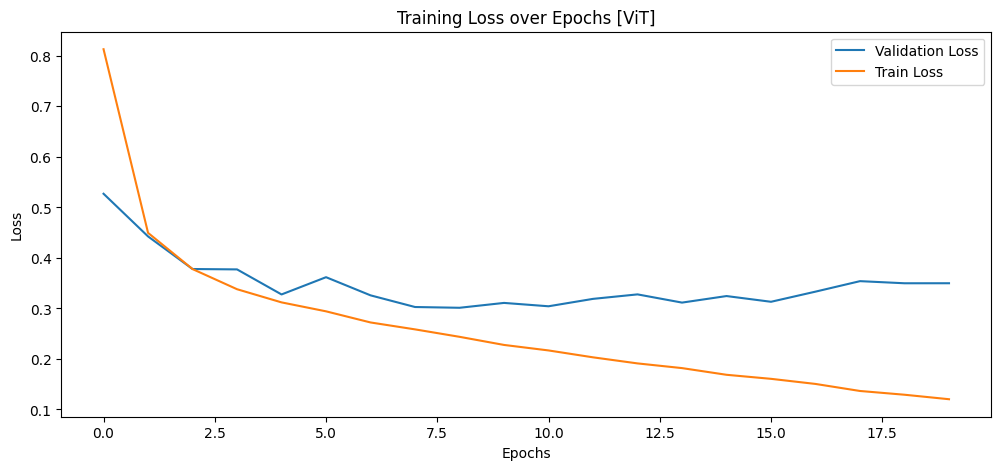

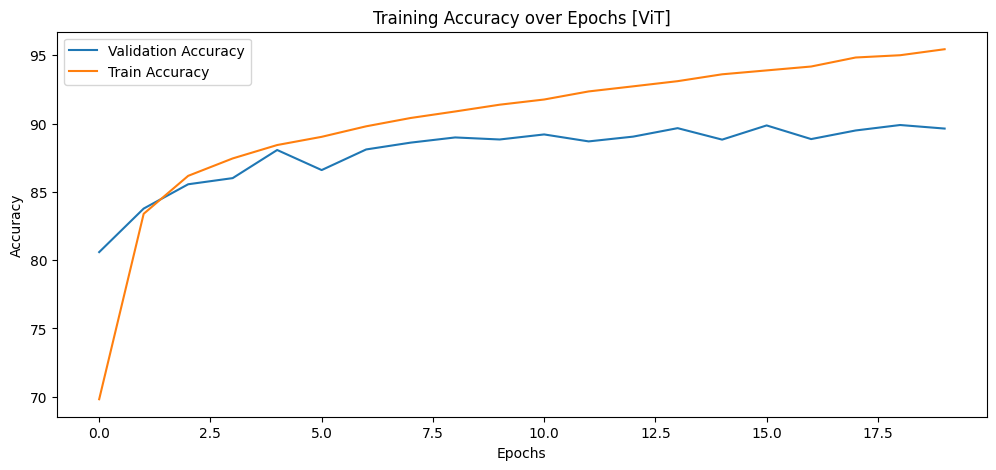

In [9]:
# Tracer les courbes de loss
plt.figure(figsize=(12, 5))
plt.plot(val_losses_vit, label='Validation Loss')
plt.plot(train_losses_vit, label='Train Loss')
plt.title('Training Loss over Epochs [ViT]')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()  

# courbe d'accuracy
plt.figure(figsize=(12, 5))
plt.plot(val_accuracies_vit, label='Validation Accuracy')
plt.plot(train_accuracies_vit, label='Train Accuracy')
plt.title('Training Accuracy over Epochs [ViT]')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

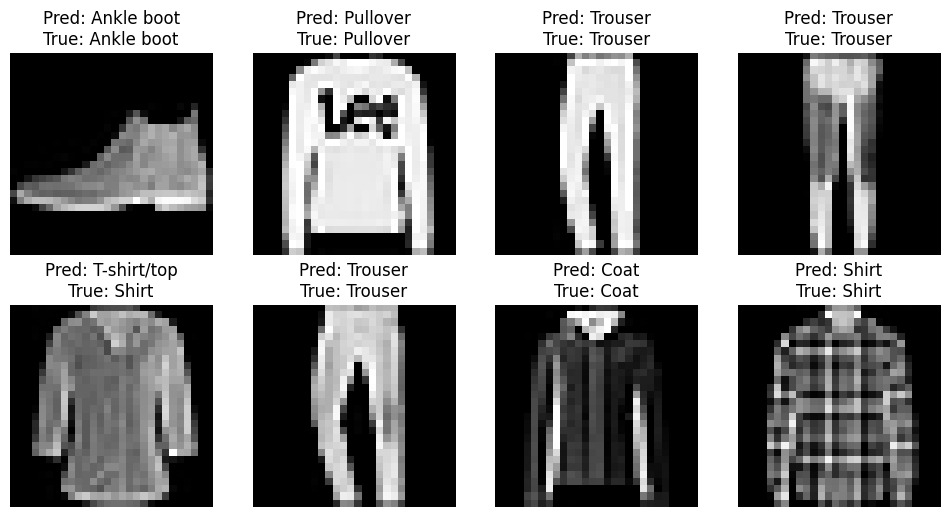

In [11]:
import matplotlib.pyplot as plt
import numpy as np

model_vit.eval()
classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
outputs = model_vit(images)
_, preds = torch.max(outputs, 1)

# Affichage de 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    img = images[i].cpu().numpy().transpose(1, 2, 0)
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"Pred: {classes[preds[i]]}\nTrue: {classes[labels[i]]}")
    ax.axis('off')
plt.show()

On obtient d'excellents résultats pour la tache de classification 10 classes sur le dataset FashionMNIST avec le ViT: 90% d'accuracy en 20 époques sans overfitting. Voici les points qui expliquent ce comportement: 

Dataset :
 - 60 000 images d’entraînement (938 batches de 64), 10 000 de test (157 batches de 64).
 - Images simples, centrées, peu de bruit, fond neutre.
 - Taille 28×28 : pas besoin d’un réseau très profond, le ViT s’adapte bien.

Pourquoi de bons résultats :
 - Les relations spatiales sont faciles à apprendre grâce à l’attention.
 - Les images sont standardisées (centrées, peu de variations), donc le modèle généralise bien sur ce dataset.
 
Limites : Si les images étaient décentrées, bruitées ou plus complexes, le modèle pourrait moins bien généraliser. Le ViT apprend surtout les relations spatiales présentes dans FashionMNIST : sur d’autres datasets plus variés, il pourrait échouer si les caractéristiques discriminantes sont différentes.

Excellente validation, peu d’overfitting, maisen grande partie du aux caractéristiques de FashionMNIST.

Nos deux architectures atteignent en 20 époque des accuracy prochent: 90 (ViT) et 91 % (CNN); mais le temps d'entrainement est beaucoup plus long pour le ViT (5m) que pour le CNN (53s). 

## Vision Transformer (ViT) vs CNN

- **Regard local vs regard global :**  
  Les CNNs examinent de petites parties de l'image à la fois (local), tandis que les ViTs analysent l'image dans son ensemble grâce à l'attention (global).

- **Connaissances pré-intégrées :**  
  Les CNNs ont des règles intégrées comme la détection de motifs proches et l'invariance aux déplacements, tandis que les ViTs doivent apprendre tout à partir des données, ce qui les rend plus flexibles mais gourmands en données.

- **Quantité de données requise :**  
  Les CNNs peuvent bien fonctionner avec peu de données, tandis que les ViTs atteignent leur meilleur résultat avec de grandes quantités de données.